# Домашнее задание 2. Исследовательский анализ данных (Python)



**Данные:** `data/Сталелитейные_данные.csv` (35 040 строк).

В ячейках замените `...` своим кодом. После каждой задачи запустите ячейку самопроверки.
Не меняйте имена результирующих переменных: они используются функцией `check`.

## Подготовительная ячейка — выполните её перед началом работы

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

DATA = Path("data")
# В папке один CSV: выбор по расширению работает и после загрузки с macOS.
DATA_FILE = next(DATA.glob("*.csv"))
NUMERIC = [
    "Usage_kWh", "Lagging_Current_Reactive_Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh", "CO2_tCO2_",
    "Lagging_Current_Power_Factor", "Leading_Current_Power_Factor",
    "Temperature_C", "Humidity_Pct",
]


def _fail(task, message):
    print(f"❌ Задание {task}: {message}")


def check(task, value):
    # Самопроверка без раскрытия полного решения.
    try:
        if value is Ellipsis or value is None:
            return _fail(task, "ответ не заполнен")
        if task == 1:
            got = tuple(pd.Timestamp(x) for x in value)
            expected = (pd.Timestamp("2018-01-01 00:00"), pd.Timestamp("2018-12-31 23:45"))
            ok = got == expected
        elif task == 2:
            ok = (isinstance(value, pd.DataFrame) and value.shape == (8, 8)
                  and np.isclose(value.loc["Temperature_C", "max"], 37.4)
                  and np.isclose(value.loc["Usage_kWh", "mean"], 27.386892))
        elif task == 3:
            expected = {"Весна": (26.9542, 32.8478, 8.5258),
                        "Зима": (32.0801, 37.1293, -12.1306),
                        "Лето": (24.4156, 30.7429, 16.7532),
                        "Осень": (26.1866, 32.3212, -4.2537)}
            got = value.set_index("Season")[["avg_usage", "std_usage", "avg_temp"]]
            ok = set(got.index) == set(expected) and all(
                np.allclose(got.loc[k].to_numpy(float), v, atol=1e-4) for k, v in expected.items())
        elif task == 4:
            got = value.to_dict() if isinstance(value, pd.Series) else dict(value)
            ok = got == {"Низкая": 11634, "Средняя": 11851, "Высокая": 11555}
        elif task == 5:
            a = np.asarray(value, dtype=float)
            variances = np.sort(np.var(a, axis=0))[::-1] if a.ndim == 2 else np.array([])
            ok = a.shape == (35040, 2) and np.allclose(variances, [3.40061, 2.33782], atol=2e-3)
        elif task == 6:
            labels = np.asarray(value)
            ok = labels.shape == (35040,) and len(np.unique(labels)) == 3
        elif task == 7:
            a = np.asarray(value)
            ok = a.shape == (2049,) and np.isclose(a[0], 0, atol=1e-8) and round(a.mean()) == 1200
        else:
            return _fail(task, "неизвестный номер")
    except Exception as exc:
        return _fail(task, f"не удалось проверить ({type(exc).__name__}: {exc})")
    print(f"{'✅' if ok else '❌'} Задание {task}" + (" выполнено" if ok else ": проверьте результат"))


print("Папка с данными найдена:", DATA.exists())
print("Файлы:", [p.name for p in DATA.iterdir()] if DATA.exists() else [])

Папка с данными найдена: True
Файлы: ['Сталелитейные_данные.csv']


## Задание 1. Временной диапазон

Прочитайте таблицу, преобразуйте `date` в `datetime64` с форматом `%d/%m/%Y %H:%M`.
Сохраните минимальную дату в `start`, максимальную — в `end`.

*Ожидаемый диапазон:* `2018-01-01 00:00:00 — 2018-12-31 23:45:00`.

In [2]:
df = pd.read_csv(DATA_FILE)
df["DateTime"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
start, end = df["DateTime"].agg(["min", "max"])

print("Диапазон:", start, "—", end)

Диапазон: 2018-01-01 00:00:00 — 2018-12-31 23:45:00


In [3]:
check(1, (start, end))

✅ Задание 1 выполнено


## Задание 2. Описательная статистика

Рассчитайте описательную статистику для восьми столбцов из списка `NUMERIC`.
Столбцы статистик должны называться `count`, `mean`, `std`, `min`, `25%`, `50%`, `75%`, `max`,
а имена признаков должны быть индексом. Сохраните таблицу в `ans`.

**Подсказка:** выберите столбцы, вызовите `.describe()` и транспонируйте результат через `.T`.

In [4]:
df = pd.read_csv(DATA_FILE)
ans = df.loc[:, NUMERIC].describe().transpose()
ans

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive_Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2_tCO2_,35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
Temperature_C,35040.0,2.320049,13.378844,-28.9,-9.40,2.10,13.7000,37.40
Humidity_Pct,35040.0,69.990499,11.655993,32.8,61.60,70.25,78.5000,98.00


In [5]:
check(2, ans)

✅ Задание 2 выполнено


## Задание 3. Статистика по сезонам

Преобразуйте дату, создайте столбец `Season`, затем для каждого сезона рассчитайте:

* среднее `Usage_kWh` → `avg_usage`;
* стандартное отклонение `Usage_kWh` → `std_usage`;
* среднее `Temperature_C` → `avg_temp`.

Сохраните итоговую таблицу со столбцом `Season` в `ans`.

In [6]:
df = pd.read_csv(DATA_FILE)
df["DateTime"] = pd.to_datetime(df["date"], format="%d/%m/%Y %H:%M")
season_by_month = {1: "Зима", 2: "Зима", 3: "Весна", 4: "Весна", 5: "Весна",
                   6: "Лето", 7: "Лето", 8: "Лето", 9: "Осень", 10: "Осень",
                   11: "Осень", 12: "Зима"}
df["Season"] = df["DateTime"].dt.month.map(season_by_month)
ans = df.groupby("Season").agg(
    avg_usage=("Usage_kWh", "mean"),
    std_usage=("Usage_kWh", "std"),
    avg_temp=("Temperature_C", "mean"),
).reset_index()
ans

,Season,avg_usage,std_usage,avg_temp
0,Весна,26.954200,32.847768,8.525770
1,Зима,32.080140,37.129322,-12.130590
2,Лето,24.415589,30.742888,16.753159
3,Осень,26.186622,32.321160,-4.253743


In [7]:
check(3, ans)

✅ Задание 3 выполнено


## Задание 4. Уровни загрузки

Найдите 33-й и 67-й процентили `Usage_kWh`. Через `pd.cut` разделите наблюдения на категории
`Низкая`, `Средняя`, `Высокая`, затем подсчитайте их с `value_counts(sort=False)`.
Сохраните количества в `ans` (Series с названиями категорий в индексе).

In [8]:
df = pd.read_csv(DATA_FILE)
q33, q67 = np.percentile(df["Usage_kWh"], [33, 67])
df["LoadLevel"] = pd.cut(
    df["Usage_kWh"],
    bins=[-np.inf, q33, q67, np.inf],
    labels=["Низкая", "Средняя", "Высокая"],
)
ans = df["LoadLevel"].value_counts(sort=False)
ans

LoadLevel
Низкая     11634
Средняя    11851
Высокая    11555
Name: count, dtype: int64

In [9]:
check(4, ans)

✅ Задание 4 выполнено


## Задание 5. Метод главных компонент

Стандартизируйте восемь числовых признаков с `StandardScaler`, обучите `PCA` с двумя
компонентами и сохраните проекцию всех строк в массив `projection` размером 35040 × 2.

In [10]:
df = pd.read_csv(DATA_FILE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[NUMERIC])
pca = PCA(n_components=2, svd_solver="full")
pca.fit(X_scaled)
projection = pca.transform(X_scaled)

print("Форма проекции:", projection.shape)

Форма проекции: (35040, 2)


/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [11]:
check(5, projection)

✅ Задание 5 выполнено


## Задание 6. Кластеризация

Стандартизируйте те же признаки. Создайте `KMeans` для трёх кластеров с
`random_state=42, n_init=20`, обучите его и сохраните метки всех строк в массив `labels`.

Помните: номера кластеров условны, поэтому сравнивать нужно состав групп, а не номер цвета.

In [12]:
df = pd.read_csv(DATA_FILE)
X_scaled = StandardScaler().fit_transform(df[NUMERIC])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
kmeans.fit(X_scaled)
labels = kmeans.labels_

print(pd.Series(labels).value_counts().sort_index())

/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/private/tmp/codex-ml-homework-2026-venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWar

0    14499
1     7677
2    12864
Name: count, dtype: int64


In [13]:
check(6, labels)

✅ Задание 6 выполнено


## Задание 7. Спектр временного ряда

Возьмите первые 4096 значений `Usage_kWh` **в исходном порядке**, вычтите среднее и примените
`np.fft.rfft`. Сохраните модуль комплексного результата в `spectrum`.

Почему ожидается 2049 значений? Для действительного сигнала отрицательная половина спектра
зеркально повторяет положительную, и `rfft` её не возвращает.

In [14]:
df = pd.read_csv(DATA_FILE)
signal = df["Usage_kWh"].to_numpy()[:4096]
signal = signal - np.mean(signal)
spectrum = np.abs(np.fft.rfft(signal))

print("Длина спектра:", len(spectrum))

Длина спектра: 2049


In [15]:
check(7, spectrum)

✅ Задание 7 выполнено


### Визуальная проверка спектра

Эту ячейку запускайте после успешного выполнения задания 7.

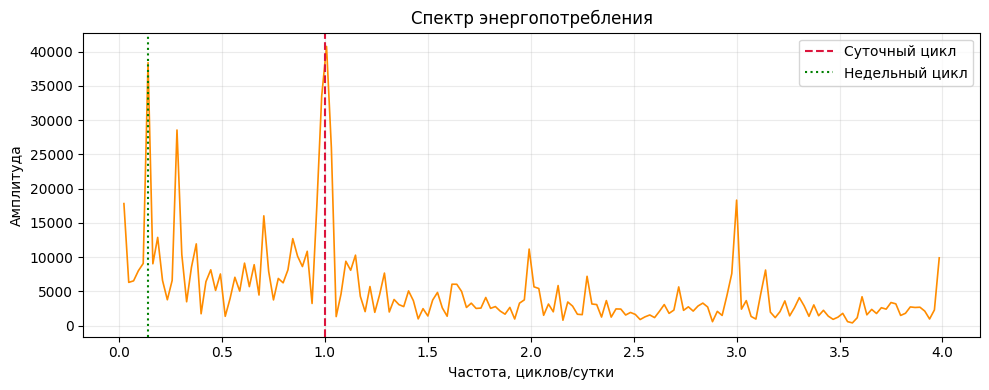

In [16]:
frequencies = np.fft.rfftfreq(4096, d=1 / 96)  # циклов в сутки
mask = (frequencies > 0) & (frequencies <= 4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frequencies[mask], spectrum[mask], linewidth=1.2, color="darkorange")
ax.axvline(1, color="crimson", linestyle="--", label="Суточный цикл")
ax.axvline(1 / 7, color="green", linestyle=":", label="Недельный цикл")
ax.set(xlabel="Частота, циклов/сутки", ylabel="Амплитуда",
       title="Спектр энергопотребления")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()